# Regularized booleans, Minkowski sums and erosions

The four regularized set operations on planar regions — Requicha's r-sets, each
answer being the closure of the operation applied to the interiors — together
with the Minkowski sum and its adjoint, the erosion. Every operation returns a
shape rather than a list of pieces, so the family is closed under composition.

[`tour.ipynb`](tour.ipynb) covers the numerics and the shape conventions these
rest on.

In [1]:
import pypgl as pgl

pgl.REPR_SVG_SIZE = 300


def figure(*layers, size=340):
    """Draw (shape, stroke, fill) layers onto one canvas, in order."""
    canvas = pgl.Canvas().size(size, size).margin(15).strokeWidth(2)
    for shape, stroke, fill in layers:
        canvas.stroke(stroke).fill(fill).draw(shape)
    return canvas

## Operands

A square and a triangle overlapping one of its corners, used throughout.

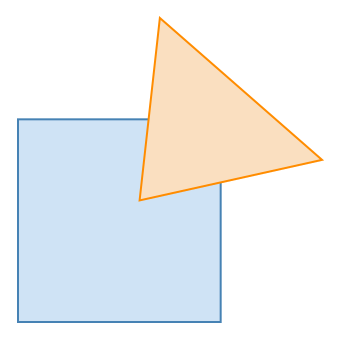

In [2]:
square = pgl.Polygon([0,0, 10,0, 10,10, 0,10])
wedge  = pgl.Triangle(6, 6, 15, 8, 7, 15)

figure((square, "steelblue", "#cfe3f5"),
       (wedge,  "darkorange", "#fadfc0"))

## The four operations

`regularizedUnion`, `difference`, `symmetricDifference` and
`regularizedIntersection` are the regularized operations
$A \cup^{*} B = \mathrm{cl}(A^{\circ} \cup B^{\circ})$ and their analogues. All
four return a [`PolygonSet`](../../doc/shapes.md#polygon-set) — finitely many
regions with pairwise disjoint interiors — whatever the operand types.

In [3]:
for name in ("regularizedUnion", "difference", "symmetricDifference"):
    result = getattr(square, name)(wedge)
    print(f"{name:22} {type(result).__name__:12} "
          f"components={result.componentCount()}  area={result.area()}")

regularizedUnion       PolygonSet   components=1  area=757/6
difference             PolygonSet   components=1  area=260/3
symmetricDifference    PolygonSet   components=2  area=677/6


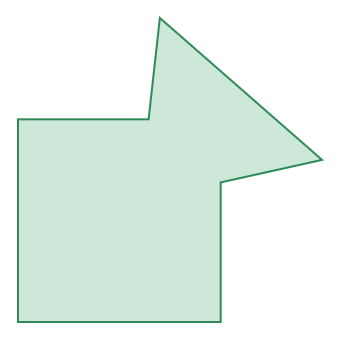

In [4]:
figure((square.regularizedUnion(wedge), "seagreen", "#cde8d8"))

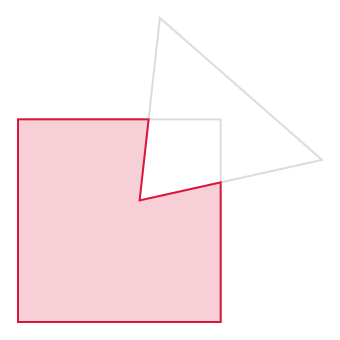

In [5]:
figure((square, "gainsboro", "none"),
       (wedge,  "gainsboro", "none"),
       (square.difference(wedge), "crimson", "#f6d0d6"))

The symmetric difference of this pair is disconnected. The two components meet
only at the two boundary crossings, and regularization discards contact of
measure zero, so the count is two rather than one.

components: 2


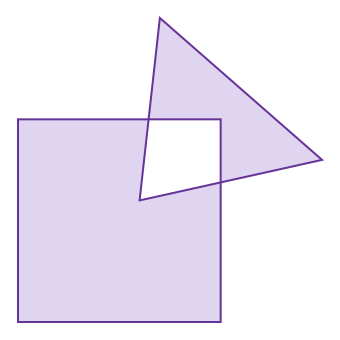

In [6]:
sym = square.symmetricDifference(wedge)
print("components:", sym.componentCount())

figure((sym, "rebeccapurple", "#e0d5f0"))

### Where the grid is not square

`regularizedIntersection` requires a `PolygonWithHoles` or a `PolygonSet` on one
side, those being the only types that can hold an answer with a hole or with
several components. A `Polygon`/`Triangle` pair therefore raises where the other
three answer.

In [7]:
try:
    square.regularizedIntersection(wedge)
except TypeError as e:
    print(str(e).splitlines()[0])

regularizedIntersection(): incompatible function arguments. The following argument types are supported:


`asPolygonWithHoles()` reaches it. The conversion is representational; the region
is unchanged.

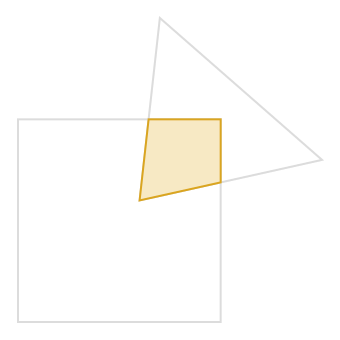

In [8]:
both = square.asPolygonWithHoles().regularizedIntersection(wedge)

figure((square, "gainsboro", "none"),
       (wedge,  "gainsboro", "none"),
       (both, "goldenrod", "#f7e9c4"))

## Closure

Each result is itself an admissible operand, so expressions compose and an answer
can be measured, drawn, transformed or compared without leaving the type
system.

components: 1   holes in the first: 1   area: 80


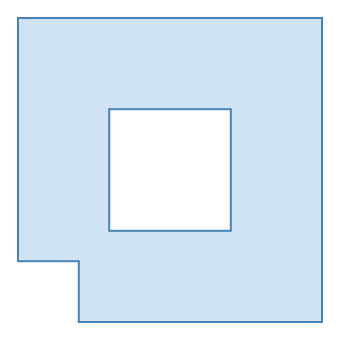

In [9]:
plate = square.difference(pgl.Rectangle(pgl.Point(3, 3), pgl.Point(7, 7)))
plate = plate.difference(pgl.Rectangle(pgl.Point(-1, -1), pgl.Point(2, 2)))

print("components:", plate.componentCount(),
      "  holes in the first:", plate.component(0).holeCount(),
      "  area:", plate.area())

figure((plate, "steelblue", "#cfe3f5"))

Subtracting from the interior creates a hole, which is what
[`PolygonWithHoles`](../../doc/shapes.md#polygon-with-holes) represents. A union
creates one as readily: a `U` united with the bar capping it encloses a hole
neither operand has.

### Regularization

Every answer is $\mathrm{cl}(\cdot^{\circ})$ of the raw set operation, so
lower-dimensional residue is discarded — shared boundary arcs, isolated contact
points, slits. Idempotence consequently holds only up to regularization:
`a.regularizedUnion(a)` is `a.regularized()`, not `a`.

In [10]:
same = square.regularizedUnion(square)

print("equal type:      ", type(same).__name__, "vs", type(square).__name__)
print("same point set:  ", same.samePointSet(square))

equal type:       PolygonSet vs Polygon
same point set:   True


`==` compares representations within a single type; `samePointSet` decides
equality of the underlying point sets across types, which is the question worth
asking here.

Since regularization discards contact of measure zero, two squares meeting at a
corner are two components:

In [11]:
a = pgl.Rectangle(pgl.Point(0, 0), pgl.Point(2, 2))
b = pgl.Rectangle(pgl.Point(2, 2), pgl.Point(4, 4))

print("components:", a.regularizedUnion(b).componentCount())

components: 2


## Minkowski sums

$A \oplus B = \{a + b : a \in A,\ b \in B\}$, written `a.minkowskiSum(b)` or
`a + b`. Convexity is preserved, and for convex bodies the support functions add:
$h_{A \oplus B} = h_A + h_B$.

Each admissible pair returns the tightest type that can hold its answer, so the
return type carries information rather than recording which operand was written
first.

In [12]:
brick = pgl.Rectangle(pgl.Point(0, 0), pgl.Point(2, 2))
ell   = pgl.Polygon([0,0, 9,0, 9,3, 3,3, 3,9, 0,9])

for pair in [(pgl.Segment(0, 0, 2, 0), pgl.Segment(0, 0, 0, 3)),
             (pgl.Triangle(0, 0, 2, 0, 0, 2), pgl.Triangle(0, 0, 1, 0, 0, 1)),
             (brick, brick),
             (ell, brick),
             (pgl.Point(3, 4), ell)]:
    r = pair[0] + pair[1]
    print(f"{type(pair[0]).__name__:10} + {type(pair[1]).__name__:10} -> "
          f"{type(r).__name__}")

Segment    + Segment    -> Convex
Triangle   + Triangle   -> Convex
Rectangle  + Rectangle  -> Rectangle
Polygon    + Rectangle  -> PolygonWithHoles
Point      + Polygon    -> Polygon


Two segments sum to the parallelogram they span, and summing with a `Point` is
translation.

The summand's position is carried into the answer. Dilating the L by a square
centred at the origin offsets every edge outward by one unit, giving the
configuration-space obstacle for a square robot — which is what reduces planning
for the robot to planning for a point.

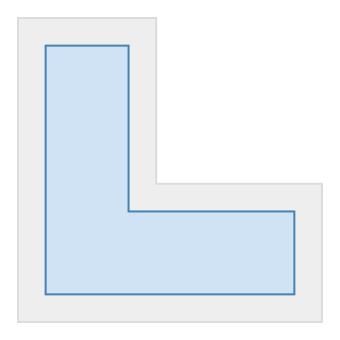

In [13]:
pad = pgl.Rectangle(pgl.Point(-1, -1), pgl.Point(1, 1))

figure((ell + pad, "gainsboro", "#eeeeee"),
       (ell,       "steelblue", "#cfe3f5"))

## Erosion

$A \ominus B = \{x : x \oplus B \subseteq A\}$, the adjoint of the sum:
$A \ominus B = (A^{c} \oplus \check{B})^{c}$ with $\check{B} = -B$. Spelled
`a.minkowskiErosion(b)`; there is no operator, `-` already denoting translation.

free positions: PolygonSet  area: 36


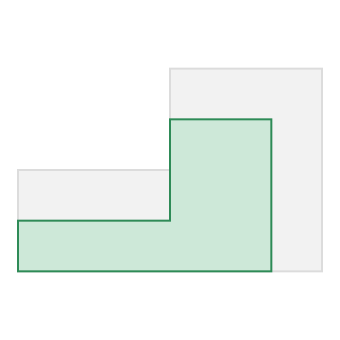

In [14]:
room = pgl.Polygon([0,0, 12,0, 12,8, 6,8, 6,4, 0,4])
free = room.minkowskiErosion(brick)

print("free positions:", type(free).__name__, " area:", free.area())

figure((room, "gainsboro", "#f2f2f2"),
       (free, "seagreen", "#cde8d8"))

The shaded region is the set of admissible translations of the brick, the room
shrunk by the brick on every side.

### Erosion does not preserve connectivity

This is the structural difference from the sum, and the reason a bounded
non-convex receiver returns a `PolygonSet` and never a single
`PolygonWithHoles`: a dumbbell eroded by anything wider than its handle separates
into two components, for operands that are in no way degenerate.

components: 2


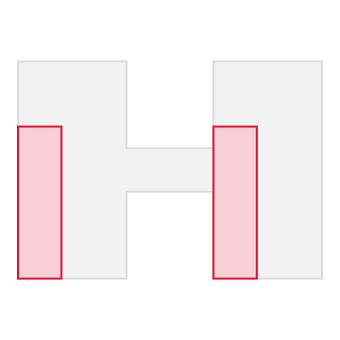

In [15]:
dumbbell = pgl.Polygon([0,0, 5,0, 5,4, 9,4, 9,0, 14,0, 14,10, 9,10, 9,6, 5,6, 5,10, 0,10])
narrow   = dumbbell.minkowskiErosion(pgl.Rectangle(pgl.Point(0, 0), pgl.Point(3, 3)))

print("components:", narrow.componentCount())

figure((dumbbell, "gainsboro", "#f2f2f2"),
       (narrow,   "crimson", "#f6d0d6"))

The handle is two units across and the brick three, so the corridor admits no
placement while both ends do.

### Convex receivers

For convex $A$, the erosion clamps each supporting half-plane by the operand's
support function and so stays within the half-plane-intersection form. A convex
receiver therefore returns a `HalfplaneIntersection` even when bounded, where the
sum would return a `Convex`; `Rectangle` $\ominus$ `Rectangle` is the one pair
closed under it.

In [16]:
tri  = pgl.Triangle(0, 0, 10, 0, 0, 10)
big  = pgl.Rectangle(pgl.Point(0, 0), pgl.Point(10, 10))

print("Triangle  erode Triangle  ->", type(tri.minkowskiErosion(pgl.Triangle(0, 0, 1, 0, 0, 1))).__name__)
print("Rectangle erode Rectangle ->", type(big.minkowskiErosion(brick)).__name__)

Triangle  erode Triangle  -> HalfplaneIntersection
Rectangle erode Rectangle -> Rectangle


The clamp reads $h_B$ and nothing else, so only the convex hull of the operand
affects the answer:

In [17]:
star = pgl.Polygon([0,0, 4,1, 8,0, 7,4, 8,8, 4,7, 0,8, 1,4])

print(tri.minkowskiErosion(star).samePointSet(tri.minkowskiErosion(star.convexHull())))

True


### Adjointness

$(A \oplus B) \ominus B = A$ for convex $A$: the opening of $A \oplus B$ by $B$ is
itself. The region survives the round trip while the type does not, which is the
situation `samePointSet` exists for.

In [18]:
A = pgl.Convex([0,0, 6,0, 7,4, 2,6])
B = pgl.Triangle(0, 0, 2, 0, 0, 2)

grown = A + B
back  = grown.minkowskiErosion(B)

print(type(A).__name__, "->", type(grown).__name__, "->", type(back).__name__)
print("back to the original region:", back.samePointSet(A))

Convex -> Convex -> HalfplaneIntersection
back to the original region: True


## Further

- [`bitmatrix.ipynb`](bitmatrix.ipynb) — the same set algebra and morphology on
  the integer grid, a machine word at a time.
- [`doc/shape_methods.md`](../../doc/shape_methods.md) — the result-type tables
  for both Minkowski operations and the admissible pairs of each boolean.
- [`doc/algorithms.md`](../../doc/algorithms.md) — `regularizedUnionOf`, which
  settles many operands in one arrangement rather than one union per step.
- [`motion.ipynb`](motion.ipynb) — the erosion applied: the free configuration
  space of a polygonal robot, and a shortest collision-free motion through it.
- [`examples/example_minkowskisum.py`](../example_minkowskisum.py) — the same
  operations as a script.